# Part 2 - Regularization & Augmentation (RGB)

Select a model with modest overfitting from Part 1, then experiment with:
- **2A:** L2 regularization (4 values)
- **2B:** Dropout (4 values)
- **2C:** Data augmentation (4 levels)
- **2D:** Combined (4 options)

Each experiment produces a 4-panel figure.

In [1]:
import torch
from os import cpu_count
from models import build_cnn
from training import get_dataloaders, train_model, get_augmentation, recommended_num_workers
from analysis import plot_4panel, plot_training_curves, print_results_table

MANIFEST = "manifests/rgb_manifest.csv"
MODALITY = "RGB"
BATCH_SIZE = 256
NUM_WORKERS = recommended_num_workers(cap=24)
PREFETCH_FACTOR = 4
EPOCHS = 70
LR = 1e-3
MIN_EPOCHS = 50
PATIENCE = 10

# SELECT THE ARCHITECTURE WITH MODEST OVERFITTING FROM PART 1
# Change this based on your Part 1 results
BASE_ARCH = "C"  # Most likely to overfit

print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"Base architecture: {BASE_ARCH}")
print(f"Logical CPUs: {cpu_count()} | DataLoader workers: {NUM_WORKERS} | Prefetch: {PREFETCH_FACTOR}")

Device: NVIDIA GeForce RTX 5090
Base architecture: C
Logical CPUs: 32 | DataLoader workers: 24 | Prefetch: 4


In [2]:
# Default data loaders (no augmentation)
train_loader, val_loader, train_df, val_df = get_dataloaders(
    MANIFEST, batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, prefetch_factor=PREFETCH_FACTOR
)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,}")

Train: 92,161 | Val: 16,136


## 2A: L2 Regularization (Weight Decay)

In [3]:
l2_values = [1e-5, 1e-4, 1e-3, 1e-2]
l2_results = []

for wd in l2_values:
    print(f"\n{'='*50}")
    print(f"L2 weight_decay = {wd}")
    print(f"{'='*50}")

    model, count = build_cnn(BASE_ARCH)
    history = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR, weight_decay=wd,
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_rgb_l2_{wd}"
    )

    l2_results.append({
        "label": f"L2={wd}",
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(l2_results)


L2 weight_decay = 1e-05


c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.3930/1.4818 | Acc: 0.5096/0.5051 | F1: 0.3604/0.3463 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.7534/0.8111 | Acc: 0.7605/0.7498 | F1: 0.7208/0.6981 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.4701/0.7259 | Acc: 0.8537/0.7969 | F1: 0.8372/0.7644 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.3978/0.5408 | Acc: 0.8765/0.8352 | F1: 0.8627/0.8123 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.3493/0.5754 | Acc: 0.8907/0.8247 | F1: 0.8794/0.8040 | LR: 1.00e-03
  Epoch  25/70 | Loss: 0.3630/1.0604 | Acc: 0.8857/0.6653 | F1: 0.8749/0.6863 | LR: 1.00e-03
  Epoch  30/70 | Loss: 0.3056/0.4573 | Acc: 0.9045/0.8587 | F1: 0.8963/0.8393 | LR: 1.00e-03
  Epoch  35/70 | Loss: 0.2745/0.4243 | Acc: 0.9137/0.8686 | F1: 0.9074/0.8537 | LR: 1.00e-03
  Epoch  40/70 | Loss: 0.2514/0.4474 | Acc: 0.9213/0.8697 | F1: 0.9164/0.8521 | LR: 1.00e-03
  Epoch  45/70 | Loss: 0.2125/0.3973 | Acc: 0.9333/0.8761 | F1: 0.9297/0.8666 | LR: 5.00e-04
  Epoch  50/70 | Loss: 0.2051/0.3895 | Acc: 0.9349/0.8731 | F1: 0.9317

c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.3777/1.4455 | Acc: 0.5137/0.5102 | F1: 0.3642/0.3570 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.7042/3.3113 | Acc: 0.7739/0.0950 | F1: 0.7517/0.0928 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.6169/0.7202 | Acc: 0.8106/0.7785 | F1: 0.7896/0.7438 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.4892/0.9965 | Acc: 0.8479/0.7195 | F1: 0.8306/0.6728 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.4264/0.5663 | Acc: 0.8681/0.8255 | F1: 0.8529/0.7937 | LR: 1.00e-03
  Epoch  25/70 | Loss: 0.3608/0.7497 | Acc: 0.8865/0.7978 | F1: 0.8748/0.7709 | LR: 1.00e-03
  Epoch  30/70 | Loss: 0.3128/0.4495 | Acc: 0.9007/0.8614 | F1: 0.8921/0.8428 | LR: 1.00e-03
  Epoch  35/70 | Loss: 0.2797/0.4585 | Acc: 0.9117/0.8611 | F1: 0.9048/0.8491 | LR: 1.00e-03
  Epoch  40/70 | Loss: 0.2550/0.4394 | Acc: 0.9197/0.8653 | F1: 0.9141/0.8523 | LR: 1.00e-03
  Epoch  45/70 | Loss: 0.2174/0.3893 | Acc: 0.9312/0.8855 | F1: 0.9268/0.8727 | LR: 5.00e-04
  Epoch  50/70 | Loss: 0.2071/0.4267 | Acc: 0.9348/0.8787 | F1: 0.9309

c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.4109/1.4640 | Acc: 0.5041/0.5022 | F1: 0.3541/0.3390 | LR: 1.00e-03
  Epoch   5/70 | Loss: 1.0063/1.0801 | Acc: 0.6725/0.6549 | F1: 0.6102/0.5976 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.7908/0.9397 | Acc: 0.7443/0.6968 | F1: 0.7112/0.6463 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.6416/0.7811 | Acc: 0.7932/0.7651 | F1: 0.7666/0.7264 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.5410/0.6608 | Acc: 0.8287/0.7969 | F1: 0.8089/0.7650 | LR: 1.00e-03
  Epoch  25/70 | Loss: 0.4597/3.9909 | Acc: 0.8558/0.5209 | F1: 0.8396/0.3728 | LR: 1.00e-03
  Epoch  30/70 | Loss: 0.4755/0.6158 | Acc: 0.8524/0.8089 | F1: 0.8360/0.7797 | LR: 1.00e-03
  Epoch  35/70 | Loss: 0.4419/0.6438 | Acc: 0.8619/0.8017 | F1: 0.8462/0.7675 | LR: 1.00e-03
  Epoch  40/70 | Loss: 0.3901/0.6794 | Acc: 0.8780/0.7971 | F1: 0.8636/0.7663 | LR: 5.00e-04
  Epoch  45/70 | Loss: 0.3729/0.5489 | Acc: 0.8820/0.8303 | F1: 0.8681/0.8023 | LR: 5.00e-04
  Epoch  50/70 | Loss: 0.3614/0.5299 | Acc: 0.8863/0.8299 | F1: 0.8732

c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.4412/1.4676 | Acc: 0.4988/0.5025 | F1: 0.3428/0.3361 | LR: 1.00e-03
  Epoch   5/70 | Loss: 1.3740/1.4501 | Acc: 0.5184/0.5040 | F1: 0.3660/0.3411 | LR: 1.00e-03
  Epoch  10/70 | Loss: 1.3441/1.4395 | Acc: 0.5243/0.5042 | F1: 0.3754/0.3419 | LR: 1.00e-03
  Epoch  15/70 | Loss: 1.3278/1.4775 | Acc: 0.5245/0.5047 | F1: 0.3761/0.3421 | LR: 1.00e-03
  Epoch  20/70 | Loss: 1.2500/1.6694 | Acc: 0.5799/0.5087 | F1: 0.4987/0.3580 | LR: 1.00e-03
  Epoch  25/70 | Loss: 1.1999/1.3800 | Acc: 0.6135/0.5377 | F1: 0.5357/0.4757 | LR: 1.00e-03
  Epoch  30/70 | Loss: 1.1267/1.2329 | Acc: 0.6460/0.6284 | F1: 0.5599/0.5290 | LR: 1.00e-03
  Epoch  35/70 | Loss: 1.0935/1.4422 | Acc: 0.6573/0.5532 | F1: 0.5627/0.4315 | LR: 1.00e-03
  Epoch  40/70 | Loss: 1.0520/1.2016 | Acc: 0.6810/0.6446 | F1: 0.5957/0.5447 | LR: 1.00e-03
  Epoch  45/70 | Loss: 1.0221/1.1503 | Acc: 0.6902/0.6629 | F1: 0.6048/0.5639 | LR: 1.00e-03
  Epoch  50/70 | Loss: 1.0168/1.1372 | Acc: 0.6923/0.6708 | F1: 0.6067

  Saved: c:\Users\Tonito\.vscode\Final-Exam-CSE-547\figures\part2a_rgb_l2.png


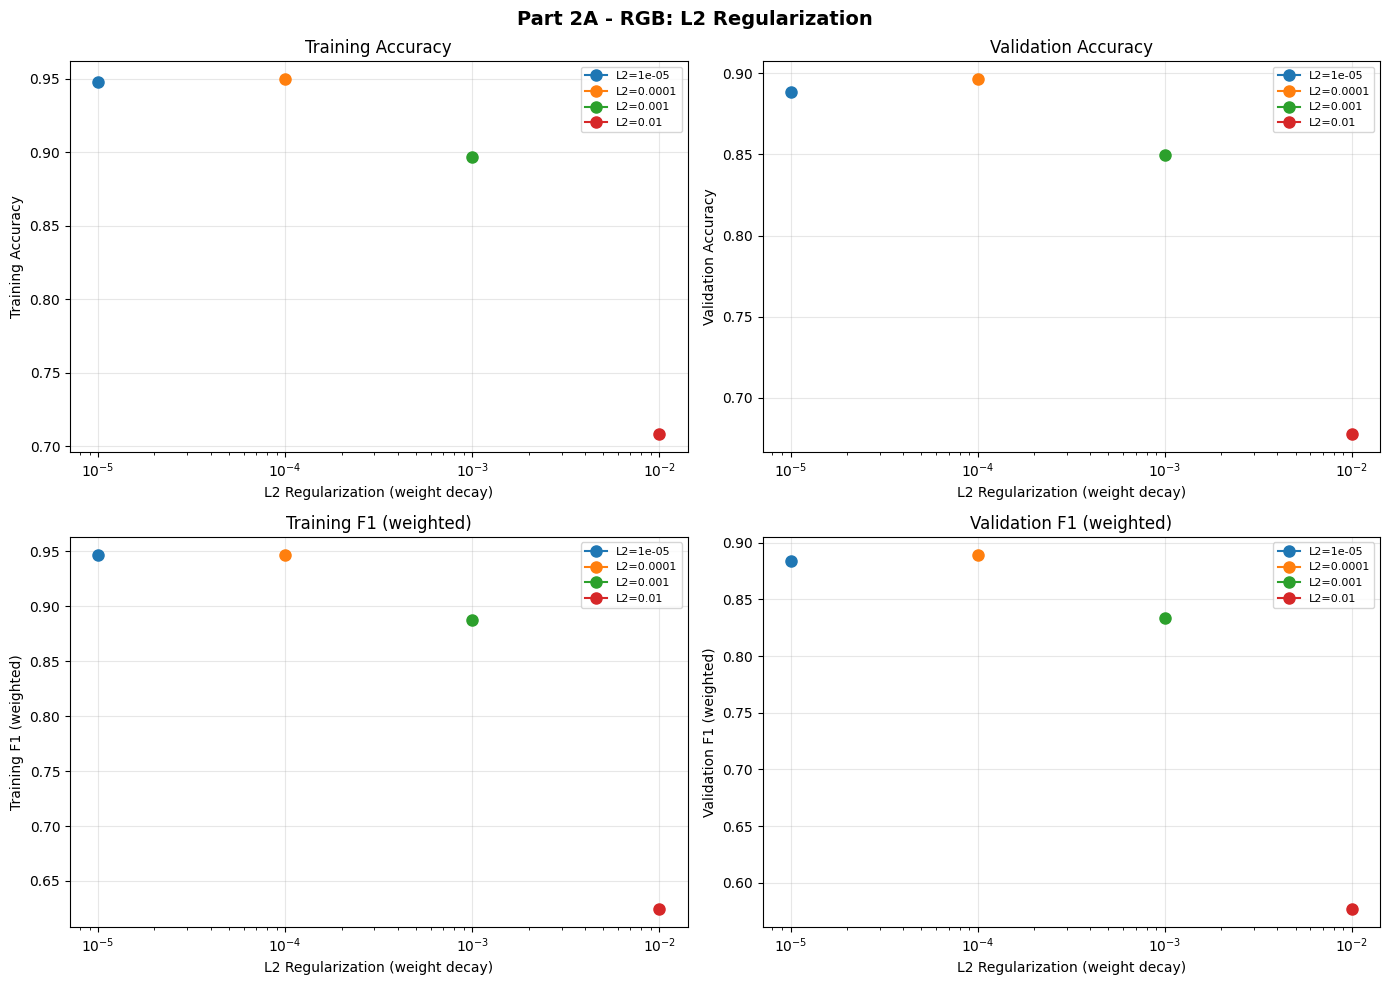

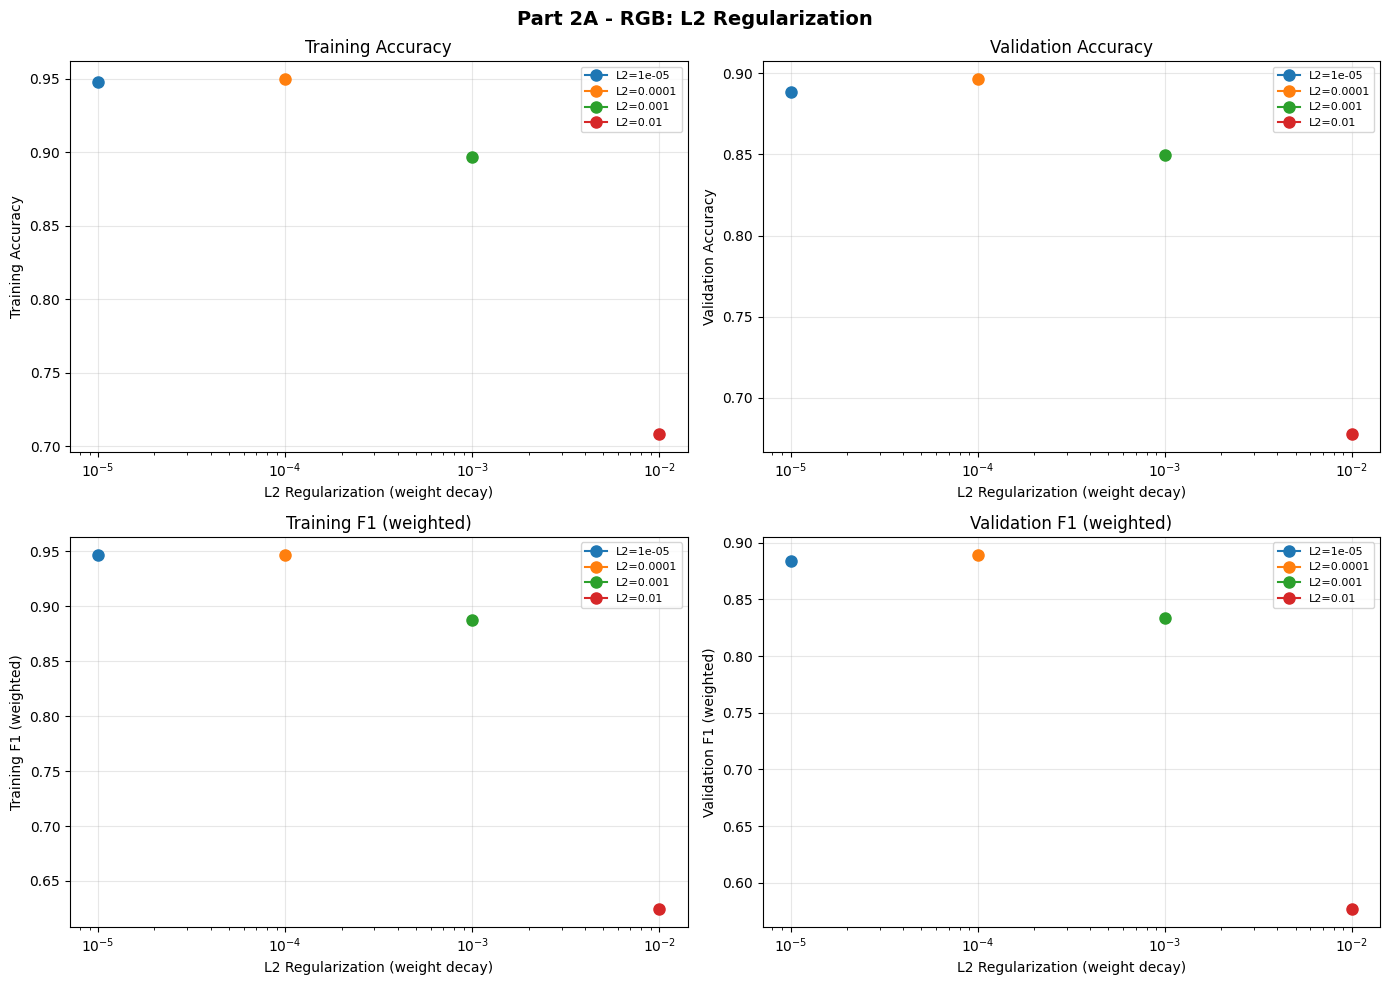

In [4]:
plot_4panel(
    l2_results, l2_values,
    x_label="L2 Regularization (weight decay)",
    title=f"Part 2A - {MODALITY}: L2 Regularization",
    x_log=True,
    save_name=f"part2a_{MODALITY.lower()}_l2.png"
)

## 2B: Dropout

In [5]:
dropout_values = [0.1, 0.25, 0.4, 0.6]
dropout_results = []

for dp in dropout_values:
    print(f"\n{'='*50}")
    print(f"Dropout = {dp}")
    print(f"{'='*50}")

    model, count = build_cnn(BASE_ARCH, dropout=dp)
    history = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR,
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_rgb_drop_{dp}"
    )

    dropout_results.append({
        "label": f"Drop={dp}",
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(dropout_results)


Dropout = 0.1


c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.3860/1.4025 | Acc: 0.5165/0.5113 | F1: 0.3660/0.3558 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.6828/0.7504 | Acc: 0.7827/0.7608 | F1: 0.7585/0.7204 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.4910/0.5793 | Acc: 0.8476/0.8239 | F1: 0.8310/0.7929 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.4081/0.5294 | Acc: 0.8743/0.8402 | F1: 0.8595/0.8124 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.3493/0.5050 | Acc: 0.8901/0.8488 | F1: 0.8783/0.8256 | LR: 1.00e-03
  Epoch  25/70 | Loss: 0.3102/0.4225 | Acc: 0.9018/0.8652 | F1: 0.8929/0.8479 | LR: 1.00e-03
  Epoch  30/70 | Loss: 0.2654/0.3872 | Acc: 0.9154/0.8811 | F1: 0.9090/0.8669 | LR: 1.00e-03
  Epoch  35/70 | Loss: 0.2354/0.3468 | Acc: 0.9237/0.8919 | F1: 0.9188/0.8799 | LR: 1.00e-03
  Epoch  40/70 | Loss: 0.2438/0.3480 | Acc: 0.9223/0.8937 | F1: 0.9176/0.8847 | LR: 1.00e-03
  Epoch  45/70 | Loss: 0.1938/0.4701 | Acc: 0.9381/0.8660 | F1: 0.9352/0.8526 | LR: 1.00e-03
  Epoch  50/70 | Loss: 0.1804/0.3496 | Acc: 0.9412/0.9001 | F1: 0.9387

c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.4207/1.4522 | Acc: 0.5094/0.5062 | F1: 0.3574/0.3440 | LR: 1.00e-03
  Epoch   5/70 | Loss: 0.8628/0.9941 | Acc: 0.7287/0.6930 | F1: 0.6882/0.6319 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.6433/0.7119 | Acc: 0.7997/0.7827 | F1: 0.7722/0.7478 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.5193/0.5840 | Acc: 0.8404/0.8226 | F1: 0.8217/0.7908 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.4633/0.5160 | Acc: 0.8587/0.8386 | F1: 0.8418/0.8080 | LR: 1.00e-03
  Epoch  25/70 | Loss: 0.4120/0.8751 | Acc: 0.8729/0.7538 | F1: 0.8574/0.7183 | LR: 1.00e-03
  Epoch  30/70 | Loss: 0.3824/0.4652 | Acc: 0.8834/0.8570 | F1: 0.8693/0.8282 | LR: 1.00e-03
  Epoch  35/70 | Loss: 0.3536/0.4191 | Acc: 0.8908/0.8693 | F1: 0.8786/0.8460 | LR: 1.00e-03
  Epoch  40/70 | Loss: 0.3257/0.4136 | Acc: 0.8984/0.8686 | F1: 0.8877/0.8485 | LR: 1.00e-03
  Epoch  45/70 | Loss: 0.3080/0.4026 | Acc: 0.9035/0.8720 | F1: 0.8940/0.8514 | LR: 1.00e-03
  Epoch  50/70 | Loss: 0.2901/0.3853 | Acc: 0.9092/0.8787 | F1: 0.9011

c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.4137/1.4229 | Acc: 0.5079/0.5108 | F1: 0.3596/0.3528 | LR: 1.00e-03
  Epoch   5/70 | Loss: 1.0207/1.3670 | Acc: 0.6712/0.5702 | F1: 0.5998/0.4663 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.7124/0.7676 | Acc: 0.7777/0.7727 | F1: 0.7556/0.7412 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.5619/0.6335 | Acc: 0.8271/0.8047 | F1: 0.8090/0.7736 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.4916/0.5484 | Acc: 0.8509/0.8296 | F1: 0.8339/0.7998 | LR: 1.00e-03
  Epoch  25/70 | Loss: 0.4437/0.5175 | Acc: 0.8665/0.8350 | F1: 0.8500/0.8052 | LR: 1.00e-03
  Epoch  30/70 | Loss: 0.4216/0.4967 | Acc: 0.8732/0.8472 | F1: 0.8572/0.8197 | LR: 1.00e-03
  Epoch  35/70 | Loss: 0.4110/0.4961 | Acc: 0.8753/0.8420 | F1: 0.8596/0.8179 | LR: 1.00e-03
  Epoch  40/70 | Loss: 0.3689/0.4438 | Acc: 0.8874/0.8600 | F1: 0.8727/0.8332 | LR: 5.00e-04
  Epoch  45/70 | Loss: 0.3567/0.4530 | Acc: 0.8914/0.8568 | F1: 0.8773/0.8342 | LR: 5.00e-04
  Epoch  50/70 | Loss: 0.3496/0.4592 | Acc: 0.8932/0.8607 | F1: 0.8795

c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


  Epoch   1/70 | Loss: 1.4881/1.4690 | Acc: 0.4907/0.5025 | F1: 0.3469/0.3361 | LR: 1.00e-03
  Epoch   5/70 | Loss: 1.0911/1.1314 | Acc: 0.6572/0.6516 | F1: 0.5885/0.5598 | LR: 1.00e-03
  Epoch  10/70 | Loss: 0.8560/0.9147 | Acc: 0.7373/0.7157 | F1: 0.6939/0.6540 | LR: 1.00e-03
  Epoch  15/70 | Loss: 0.7531/0.7822 | Acc: 0.7694/0.7619 | F1: 0.7291/0.7054 | LR: 1.00e-03
  Epoch  20/70 | Loss: 0.7036/0.7080 | Acc: 0.7849/0.7833 | F1: 0.7499/0.7367 | LR: 1.00e-03
  Epoch  25/70 | Loss: 0.6449/0.7084 | Acc: 0.8025/0.7868 | F1: 0.7742/0.7485 | LR: 1.00e-03
  Epoch  30/70 | Loss: 0.6057/0.6527 | Acc: 0.8142/0.8027 | F1: 0.7889/0.7701 | LR: 1.00e-03
  Epoch  35/70 | Loss: 0.5804/0.6581 | Acc: 0.8232/0.8026 | F1: 0.8009/0.7710 | LR: 1.00e-03
  Epoch  40/70 | Loss: 0.5610/0.6060 | Acc: 0.8302/0.8176 | F1: 0.8090/0.7849 | LR: 1.00e-03
  Epoch  45/70 | Loss: 0.5403/0.5615 | Acc: 0.8368/0.8312 | F1: 0.8169/0.7988 | LR: 1.00e-03
  Epoch  50/70 | Loss: 0.5270/0.5857 | Acc: 0.8414/0.8267 | F1: 0.8223

  Saved: c:\Users\Tonito\.vscode\Final-Exam-CSE-547\figures\part2b_rgb_dropout.png


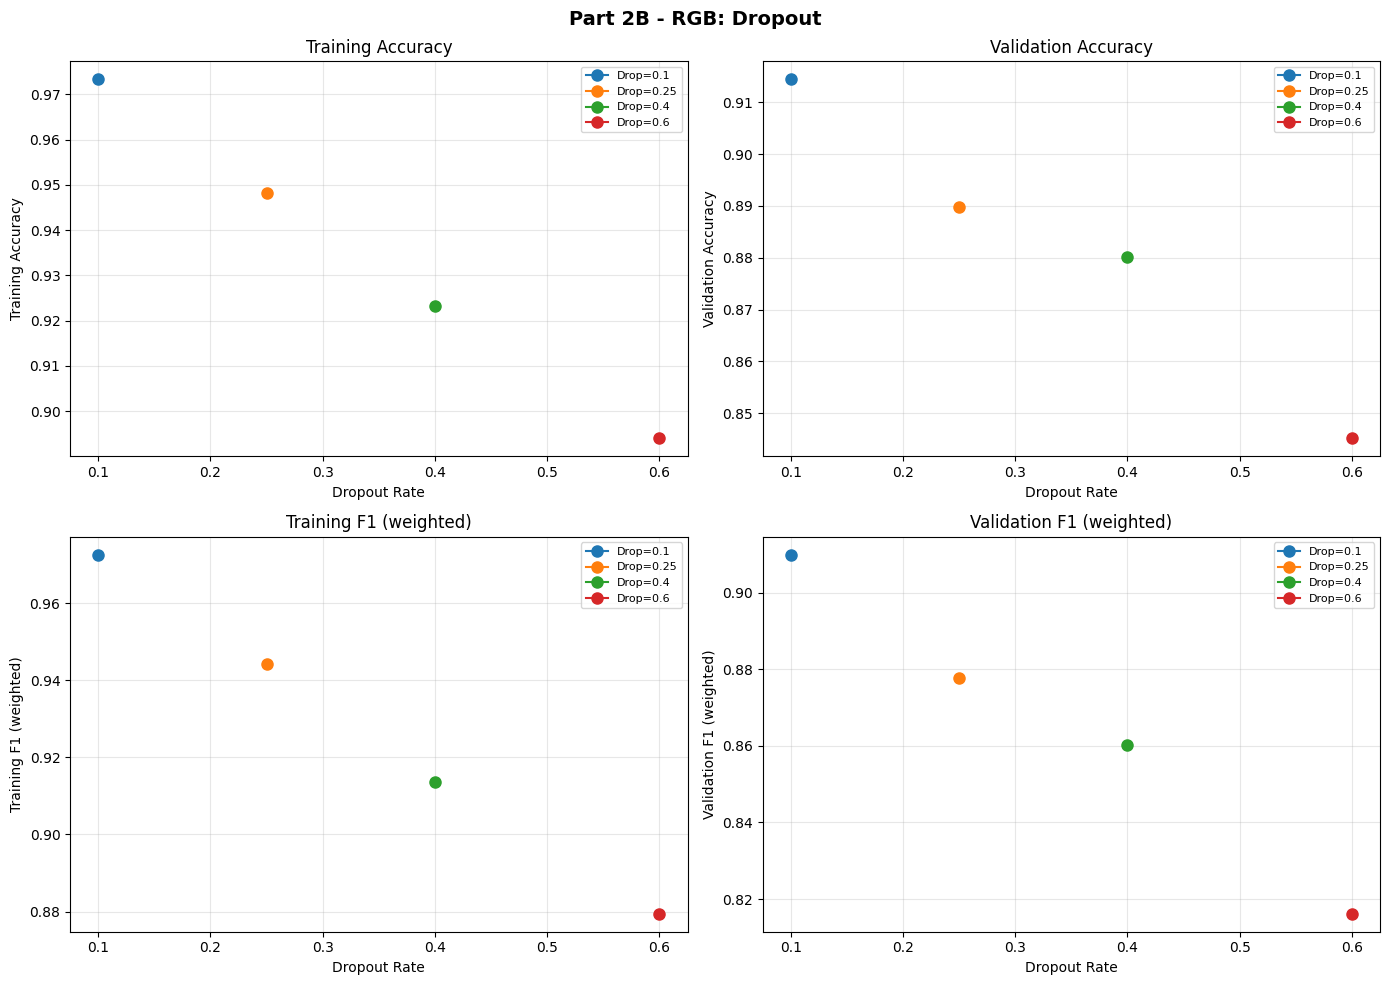

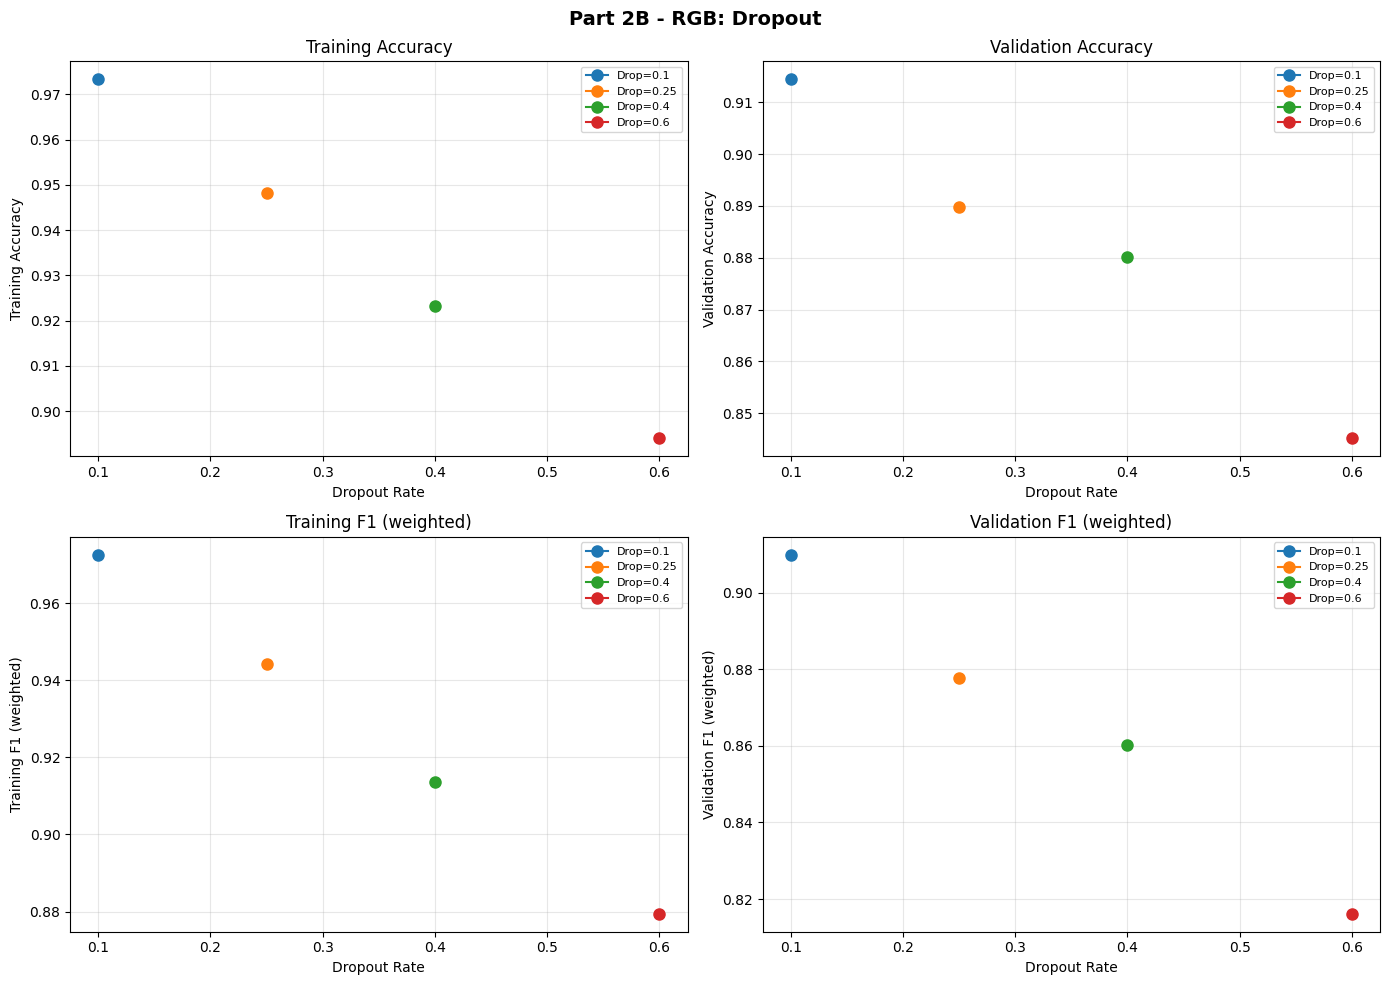

In [6]:
plot_4panel(
    dropout_results, dropout_values,
    x_label="Dropout Rate",
    title=f"Part 2B - {MODALITY}: Dropout",
    save_name=f"part2b_{MODALITY.lower()}_dropout.png"
)

## 2C: Data Augmentation

In [ ]:
from torchvision import transforms

aug_levels = [1, 2, 3, 4]
aug_labels = ["Flip only", "Flip+Rot10+Affine", "Flip+Rot20+Affine+Color", "Flip+Rot30+Affine+StrongColor"]
aug_results = []

val_transform = get_augmentation(0)  # No augmentation for validation

for level, label in zip(aug_levels, aug_labels):
    print(f"\n{'='*50}")
    print(f"Augmentation Level {level}: {label}")
    print(f"{'='*50}")

    train_transform = get_augmentation(level)
    aug_train_loader, aug_val_loader, _, _ = get_dataloaders(
        MANIFEST, batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS, prefetch_factor=PREFETCH_FACTOR,
        train_transform=train_transform, val_transform=val_transform
    )

    model, count = build_cnn(BASE_ARCH)
    history = train_model(
        model, aug_train_loader, aug_val_loader,
        epochs=EPOCHS, lr=LR,
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_rgb_aug_{level}"
    )

    aug_results.append({
        "label": f"Aug L{level}",
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(aug_results)


Augmentation Level 1: Flip only


c:\Users\Tonito\.vscode\Final-Exam-CSE-547\training.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


In [ ]:
plot_4panel(
    aug_results, aug_levels,
    x_label="Augmentation Level",
    title=f"Part 2C - {MODALITY}: Data Augmentation",
    save_name=f"part2c_{MODALITY.lower()}_augmentation.png"
)

## 2D: Combined (Best L2 + Dropout + Augmentation)

In [ ]:
# Identify best from each experiment above
best_l2 = l2_values[max(range(len(l2_results)), key=lambda i: l2_results[i]["best_val_f1"])]
best_dp = dropout_values[max(range(len(dropout_results)), key=lambda i: dropout_results[i]["best_val_f1"])]
best_aug = aug_levels[max(range(len(aug_results)), key=lambda i: aug_results[i]["best_val_f1"])]

print(f"Best L2: {best_l2}")
print(f"Best Dropout: {best_dp}")
print(f"Best Augmentation Level: {best_aug}")

# 4 combined configurations
combined_configs = [
    {"label": f"L2={best_l2}+Drop={best_dp}",
     "wd": best_l2, "dp": best_dp, "aug": 0},
    {"label": f"L2={best_l2}+Aug={best_aug}",
     "wd": best_l2, "dp": 0.0, "aug": best_aug},
    {"label": f"Drop={best_dp}+Aug={best_aug}",
     "wd": 0.0, "dp": best_dp, "aug": best_aug},
    {"label": f"L2+Drop+Aug (all best)",
     "wd": best_l2, "dp": best_dp, "aug": best_aug},
]

In [ ]:
combined_results = []
val_transform = get_augmentation(0)

for i, cfg in enumerate(combined_configs):
    print(f"\n{'='*50}")
    print(f"Combined {i+1}: {cfg['label']}")
    print(f"{'='*50}")

    train_transform = get_augmentation(cfg["aug"])
    c_train_loader, c_val_loader, _, _ = get_dataloaders(
        MANIFEST, batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS, prefetch_factor=PREFETCH_FACTOR,
        train_transform=train_transform, val_transform=val_transform
    )

    model, count = build_cnn(BASE_ARCH, dropout=cfg["dp"])
    history = train_model(
        model, c_train_loader, c_val_loader,
        epochs=EPOCHS, lr=LR, weight_decay=cfg["wd"],
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part2_rgb_combined_{i}"
    )

    combined_results.append({
        "label": cfg["label"],
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })
    del model
    torch.cuda.empty_cache()

print_results_table(combined_results)

In [ ]:
plot_4panel(
    combined_results, list(range(1, 5)),
    x_label="Combined Configuration",
    title=f"Part 2D - {MODALITY}: Combined Regularization + Augmentation",
    save_name=f"part2d_{MODALITY.lower()}_combined.png"
)

## Summary

In [ ]:
print(f"\n{'='*60}")
print(f"Part 2 {MODALITY} Summary")
print(f"{'='*60}")
print("\n2A - L2 Regularization:")
print_results_table(l2_results)
print("\n2B - Dropout:")
print_results_table(dropout_results)
print("\n2C - Data Augmentation:")
print_results_table(aug_results)
print("\n2D - Combined:")
print_results_table(combined_results)